## 1. Mount Google Drive

Menghubungkan Google Colab dengan Google Drive agar dataset dan file output dapat diakses.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Import Library

Mengimpor seluruh library yang dibutuhkan: OpenCV, NumPy, Pandas, Scikit-learn, Matplotlib, Seaborn, dan Scikit-image.

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage import feature, exposure
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

## 3. Load Dataset

Membaca semua path gambar dari folder `normal` dan `unnormal`, kemudian membuat daftar label (0 = Normal, 1 = Pneumonia).

In [ ]:
base_dir = "/content/drive/MyDrive/Colab Notebooks/Pneumonia"
categories = ['normal', 'unnormal']

image_paths = []
labels = []

for category in categories:
    folder = os.path.join(base_dir, 'train', category)
    if not os.path.exists(folder):
        folder = os.path.join(base_dir, category)  # fallback
    for f in os.listdir(folder):
        if f.endswith(('.jpeg', '.jpg', '.png')):
            image_paths.append(os.path.join(folder, f))
            labels.append(0 if category == 'normal' else 1)

print(f"Total gambar: {len(image_paths)}")
print(f"Normal (0): {labels.count(0)}")
print(f"Pneumonia (1): {labels.count(1)}")

Total gambar: 232
Normal (0): 116
Pneumonia (1): 116


## 4. Definisi Fungsi Ekstraksi Fitur

Mendefinisikan fungsi `extract_xray_features()` yang mengekstrak:
- **Statistik Intensitas**: Mean, Std, Skewness, Kurtosis
- **GLCM**: Contrast, Dissimilarity, Homogeneity, Energy, Correlation
- **LBP**: Histogram 10 bin (Local Binary Pattern)
- **HOG**: Mean & Std dari deskriptor HOG

In [ ]:
def extract_xray_features(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (256, 256))

    # === 1. Statistik intensitas ===
    mean_int = np.mean(img)
    std_int = np.std(img)
    skew = np.mean(((img - mean_int)/std_int)**3) if std_int > 0 else 0
    kurt = np.mean(((img - mean_int)/std_int)**4) - 3 if std_int > 0 else 0

    # === 2. GLCM (kontras, dissimilarity, homogeneity, energy, correlation) ===
    glcm = feature.graycomatrix(img, distances=[1], angles=[0],
                                levels=256, symmetric=True, normed=True)
    contrast = feature.graycoprops(glcm, 'contrast')[0,0]
    dissimilarity = feature.graycoprops(glcm, 'dissimilarity')[0,0]
    homogeneity = feature.graycoprops(glcm, 'homogeneity')[0,0]
    energy = feature.graycoprops(glcm, 'energy')[0,0]
    correlation = feature.graycoprops(glcm, 'correlation')[0,0]

    # === 3. LBP (uniform, 10 bin) ===
    lbp = feature.local_binary_pattern(img, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)

    # === 4. HOG (mean dan std dari deskriptor) ===
    hog = feature.hog(img, orientations=9, pixels_per_cell=(32,32),
                      cells_per_block=(1,1), visualize=False)
    hog_mean = np.mean(hog)
    hog_std = np.std(hog)

    # === Kumpulkan fitur ===
    features = {
        'mean_int': mean_int, 'std_int': std_int,
        'skewness': skew, 'kurtosis': kurt,
        'glcm_contrast': contrast, 'glcm_dissimilarity': dissimilarity,
        'glcm_homogeneity': homogeneity, 'glcm_energy': energy,
        'glcm_correlation': correlation,
        'hog_mean': hog_mean, 'hog_std': hog_std
    }
    # Tambahkan LBP bins
    for i in range(10):
        features[f'lbp_bin_{i}'] = lbp_hist[i] if i < len(lbp_hist) else 0

    return features

## 5. Proses Ekstraksi Fitur pada Semua Gambar

Menjalankan fungsi ekstraksi fitur untuk setiap gambar dan menyimpan hasilnya ke dalam DataFrame `df`.

In [ ]:
print("Ekstraksi fitur (proses bisa memakan waktu beberapa menit)...")
all_features = []
for idx, path in enumerate(image_paths):
    if idx % 500 == 0:
        print(f"Proses {idx+1}/{len(image_paths)}")
    feat = extract_xray_features(path)
    if feat is not None:
        feat['filename'] = os.path.basename(path)
        all_features.append(feat)

df = pd.DataFrame(all_features)
print(f"Dataset fitur: {df.shape}")
df.head()

Ekstraksi fitur (proses bisa memakan waktu beberapa menit)...
Proses 1/232
Dataset fitur: (232, 22)


,mean_int,std_int,skewness,kurtosis,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,glcm_energy,glcm_correlation,hog_mean,...,lbp_bin_1,lbp_bin_2,lbp_bin_3,lbp_bin_4,lbp_bin_5,lbp_bin_6,lbp_bin_7,lbp_bin_8,lbp_bin_9,filename
0,136.220551,55.224463,-0.386879,-0.598541,133.808808,7.377773,0.159905,0.015113,0.977955,0.320049,...,0.087326,0.057480,0.089508,0.125183,0.100235,0.070724,0.087540,0.114807,0.174316,IM-0005-0001.jpeg
1,151.438553,44.056634,-0.425292,-0.449030,93.389568,6.107430,0.174081,0.016890,0.975938,0.326494,...,0.085648,0.060226,0.089066,0.123077,0.104095,0.073135,0.086533,0.116928,0.169220,IM-0021-0001.jpeg
2,143.397980,51.650015,-0.094243,-0.683367,129.485371,7.370695,0.151632,0.014536,0.975567,0.322012,...,0.084503,0.060059,0.092941,0.139771,0.112778,0.071152,0.083725,0.106171,0.163071,IM-0033-0001.jpeg
3,137.665115,53.786278,-0.223531,-0.622503,134.243934,7.524326,0.152903,0.014103,0.976705,0.321188,...,0.086761,0.059616,0.090530,0.135345,0.104828,0.070587,0.086044,0.109787,0.168030,IM-0007-0001.jpeg
4,130.725189,58.543207,-0.244252,-0.927828,129.716176,7.310355,0.160351,0.015705,0.981021,0.324570,...,0.090408,0.055832,0.079788,0.118240,0.093185,0.067337,0.091354,0.121109,0.183914,IM-0035-0001.jpeg


## 6. Tambahkan Kolom Label & Persiapan Fitur (X, y)

Menambahkan kolom `label` ke DataFrame, memisahkan fitur input `X` dan target `y`, serta melakukan normalisasi dengan `StandardScaler`.

In [ ]:
df['label'] = labels[:len(df)]

# Hapus baris yang mungkin gagal ekstraksi (tidak ada)
df = df.dropna()
print(f"Setelah pembersihan: {df.shape}")

# Pisahkan X dan y
X = df.drop(['filename', 'label'], axis=1).values
y = df['label'].values

print(f"Dimensi X: {X.shape}, kelas unik: {np.unique(y)}")

Setelah pembersihan: (232, 23)
Dimensi X: (232, 21), kelas unik: [0 1]


## 7. Split Data — Train & Test

Membagi dataset menjadi **80% data latih** dan **20% data uji** menggunakan `train_test_split` dengan stratifikasi kelas.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Distribusi kelas train: {np.bincount(y_train)}")
print(f"Distribusi kelas test: {np.bincount(y_test)}")

# Standarisasi (fit hanya pada train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: 185, Test: 47
Distribusi kelas train: [92 93]
Distribusi kelas test: [24 23]


## 8. Training Model Random Forest

Melatih model **Random Forest Classifier** dengan 100 pohon keputusan (`n_estimators=100`), lalu mengevaluasi akurasi pada data uji dan menampilkan *classification report*.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Akurasi test: {acc:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Pneumonia']))



Akurasi test: 97.87%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98        24
   Pneumonia       1.00      0.96      0.98        23

    accuracy                           0.98        47
   macro avg       0.98      0.98      0.98        47
weighted avg       0.98      0.98      0.98        47



## 9. Visualisasi Confusion Matrix

Menampilkan **Confusion Matrix** dalam bentuk heatmap untuk melihat distribusi prediksi benar dan salah antara kelas Normal dan Pneumonia.

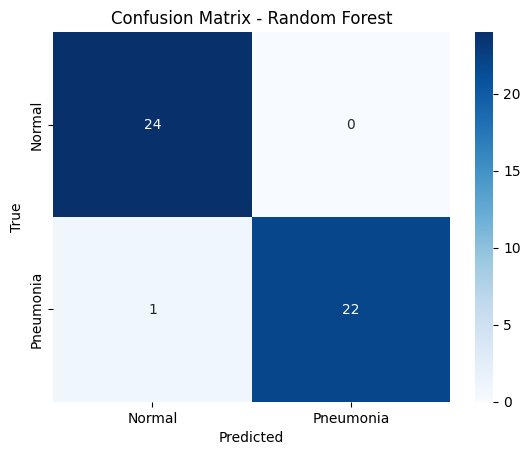

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

## 10. Analisis Feature Importance

Menampilkan **10 fitur terpenting** yang paling berkontribusi dalam prediksi model Random Forest, diurutkan berdasarkan nilai importance.

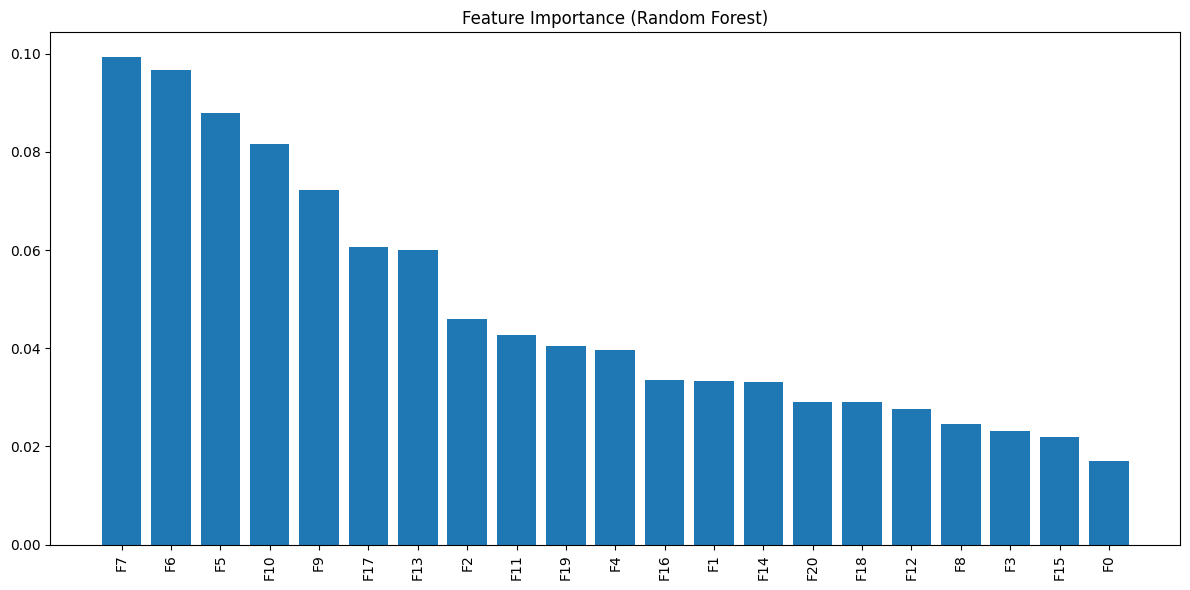

Top 10 fitur terpenting:
1. F7: 0.0994
2. F6: 0.0967
3. F5: 0.0880
4. F10: 0.0816
5. F9: 0.0722
6. F17: 0.0607
7. F13: 0.0600
8. F2: 0.0460
9. F11: 0.0427
10. F19: 0.0405


In [ ]:
importances = rf.feature_importances_
feature_names = X.columns if hasattr(X, 'columns') else [f'F{i}' for i in range(X.shape[1])]
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

print("Top 10 fitur terpenting:")
for i in range(10):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

## 11. Simpan Dataset Fitur ke Google Drive

Menyimpan DataFrame hasil ekstraksi fitur (`df`) ke file CSV di Google Drive sebagai output akhir.

In [ ]:
import os

save_dir = '/content/drive/MyDrive/Colab Notebooks/HasilEkstraksiPneumonia'
os.makedirs(save_dir, exist_ok=True)   # Pastikan folder ada

# Simpan dataset fitur
df.to_csv(os.path.join(save_dir, 'pneumonia_features.csv'), index=False)

print(f"dataset fitur disimpan di: {save_dir}")

dataset fitur disimpan di: /content/drive/MyDrive/Colab Notebooks/HasilEkstraksiPneumonia
